# NLP Tutorial: Feature Engineering (Text Representation) - Bag of Words (BoW)

Let's download a dataset from the Codebasics NLP tutorials GitHub repository:

In [1]:
!wget -O spam.csv https://raw.githubusercontent.com/codebasics/nlp-tutorials/main/9_bag_of_words/spam.csv

--2026-09-27 09:37:04--  https://raw.githubusercontent.com/codebasics/nlp-tutorials/main/9_bag_of_words/spam.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 480130 (469K) [text/plain]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 468.88K  --.-KB/s    in 0.04s   

2026-09-27 09:37:05 (11.8 MB/s) - ‘spam.csv’ saved [480130/480130]



In [2]:
import pandas as pd
import numpy as np

Load the dataset into a Pandas DataFrame.

In [4]:
df = pd.read_csv('spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


The DataFrame has one column named `Category` with values such as `spam` and `ham` (not spam). We encode these labels into binary values:

- `1` for spam
- `0` for non-spam

This makes it easier to train a binary classification model later.

In [9]:
df["spam"] = df["Category"].apply(lambda x: 1 if x == "spam" else 0)
df.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [13]:
df["spam"].value_counts()

,count
spam,
0,4825
1,747


In [10]:
df.shape # 5572 rows and 3 columns

(5572, 3)

## Train/Test split

In [19]:
from sklearn.model_selection import train_test_split

X = df.Message
y = df.spam

# 80/20 stratefied=y

X_train, X_test, y_train, y_test = train_test_split(df.Message, df.spam, test_size=0.20,stratify=y)

In [34]:
print("X_train.shape:",X_train.shape[0],"rows", "| X_test:",X_test.shape[0] ,"rows", "| total rows",df.shape[0])
print("y_train spam (1) rate:", y_train.mean()*100, "%")
print("y_test spam (1) rate:", y_test.mean()*100, "%")

X_train.shape: 4457 rows | X_test: 1115 rows | total rows 5572
y_train spam (1) rate: 13.417096701817366 %
y_test spam (1) rate: 13.363228699551568 %


## Create a Bag-of-Words representation using `scikit-learn`'s `CountVectorizer`

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer()

X_train_cv = v.fit_transform(X_train.values)
X_train_cv

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 58750 stored elements and shape (4457, 7730)>

**Note**: `CountVectorizer` performs basic preprocessing such as lowercasing and tokenization, but it does not apply advanced text cleaning operations like stemming, lemmatization, or URL removal.

### Accessing the vocabulary

The vocabulary learned by `CountVectorizer` can be accessed using:

```python
v.vocabulary_
```

This returns a dictionary that maps each token to its index in the Bag-of-Words matrix.

In [36]:
# Bag-of-Words vector shape
X_train_cv.shape[1]

7730

In [37]:
v.vocabulary_ # words take index from 0 to 7730

{'no': 4773,
 'yes': 7672,
 'please': 5230,
 'been': 1287,
 'swimming': 6637,
 'the': 6792,
 'sign': 6140,
 'of': 4868,
 'maturity': 4368,
 'is': 3733,
 'not': 4809,
 'when': 7463,
 'we': 7396,
 'start': 6427,
 'saying': 5915,
 'big': 1344,
 'things': 6822,
 'but': 1573,
 'actually': 806,
 'it': 3745,
 'understanding': 7121,
 'small': 6223,
 'have': 3345,
 'nice': 4749,
 'evening': 2661,
 'bslvyl': 1530,
 'sorry': 6312,
 'sir': 6167,
 'will': 7502,
 'call': 1604,
 'you': 7687,
 'tomorrow': 6939,
 'senthil': 6008,
 'hsbc': 3522,
 'thank': 6780,
 'winner': 7514,
 'notified': 4817,
 'by': 1588,
 'sms': 6246,
 'good': 3176,
 'luck': 4229,
 'future': 3045,
 'marketing': 4335,
 'reply': 5701,
 'stop': 6472,
 'to': 6913,
 '84122': 670,
 'customer': 2129,
 'services': 6019,
 '08450542832': 67,
 'babe': 1184,
 'miiiiiiissssssssss': 4449,
 'need': 4705,
 'crave': 2061,
 'geeee': 3090,
 'so': 6265,
 'sad': 5860,
 'without': 7534,
 'love': 4200,
 'tell': 6733,
 'my': 4641,
 'bad': 1194,
 'characte

# Train the model (Naive Bayes) using a scikit-learn pipeline

The model performs binary classification with two classes:

- `0` = non-spam
- `1` = spam

Instead of manually converting `X_train` into a Bag-of-Words matrix, we can combine vectorization and classification into a single `Pipeline` object.

The pipeline automatically performs the following steps:

1. **Vectorization**: `CountVectorizer` learns the vocabulary from `X_train` and converts the text into a Bag-of-Words representation.
2. **Classification**: `MultinomialNB` is then trained on the resulting numerical features.

In [49]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

## Train the model

In [53]:
model.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

## Model Evaluation

### Make predictions on `X_test`

In [54]:
y_pred = model.predict(X_test)

After generating predictions on the test set, we evaluate the classifier using a classification report and a confusion matrix.

The `classification_report` provides several evaluation metrics for each class:

- **Precision**: proportion of predicted positive samples that are actually positive.
- **Recall**: proportion of actual positive samples that are correctly identified.
- **F1-score**: harmonic mean of precision and recall.
- **Support**: number of samples in each class.

The `confusion_matrix` shows how predictions are distributed between the actual and predicted classes. It helps identify both correct classifications and misclassifications.

### Classification report

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



### Confusion matrix

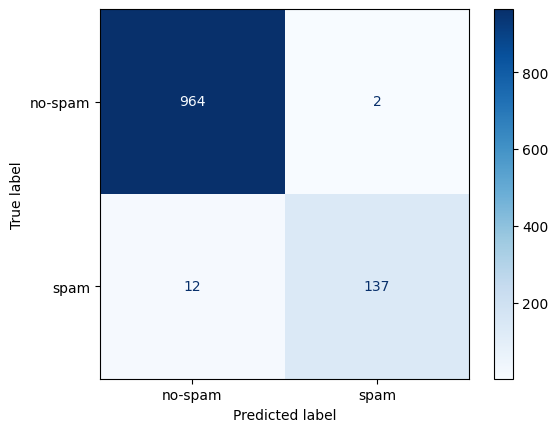

In [56]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["no-spam", "spam"]
)

disp.plot(cmap="Blues")